<a href="https://colab.research.google.com/github/masum-mir/machine-learning-journey/blob/main/data_splitting_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Splitting Techniques in Machine Learning

**Techniques covered:**

1. Random Hold-Out
2. Shuffled Hold-Out
3. Two-Way Hold-Out
4. Three-Way Hold-Out
5. Stratified Two-Way Hold-Out
6. Stratified Three-Way Hold-Out
7. k-Fold Cross-Validation
8. Stratified k-Fold
9. Repeated k-Fold
10. Repeated Stratified k-Fold
11. Leave-p-Out Cross-Validation (LpOCV)
12. Shuffle Split Cross-Validation
13. Stratified Shuffle Split
14. Group K-Fold Cross-Validation
15. Stratified Group k-Fold
16. Bootstrap Sampling (with replacement)


In [ ]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    LeavePOut,
    RepeatedKFold,
    RepeatedStratifiedKFold,
    ShuffleSplit,
    StratifiedShuffleSplit,
    GroupKFold,
    cross_val_score,
    cross_validate,
)
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_SGKF = True
except ImportError:
    HAS_SGKF = False
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import LabelEncoder

In [ ]:

results = {}


In [ ]:
# 1. Load and inspect the dataset
df = pd.read_csv("heart.csv")
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print("\nClass counts:")
print(y.value_counts().sort_index())

display(X.head())


Feature matrix shape : (918, 11)
Target shape         : (918,)

Class counts:
HeartDisease
0    410
1    508
Name: count, dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,1,1,140,289,0,1,172,0,0.0,2
1,49,0,2,160,180,0,1,156,0,1.0,1
2,37,1,1,130,283,0,2,98,0,0.0,2
3,48,0,0,138,214,0,1,108,1,1.5,1
4,54,1,2,150,195,0,1,122,0,0.0,2



---
## 1. Random Hold-Out



Train Accuracy: 100.0
Test Accuracy: 88.04347826086956


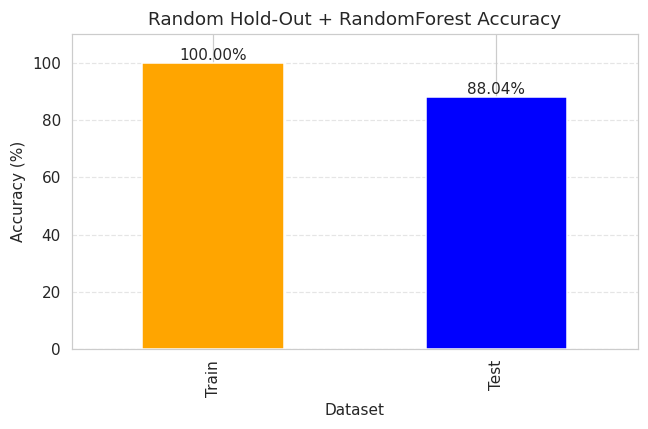

In [ ]:
# 1.Random Hold-Out Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model create
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Train model
model.fit(X_train, y_train)

# Prediction
train_acc = accuracy_score(y_train, model.predict(X_train)) * 100
test_acc = accuracy_score(y_test, model.predict(X_test)) * 100

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Bar Chart
acc_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_acc, test_acc]
})

results["1. Random Hold-Out"] = test_acc

ax = acc_df.plot(
    x="Dataset",
    y="Accuracy",
    kind="bar",
    figsize=(6, 4),
    legend=False,
    color=["orange", "blue"]
)

plt.title("Random Hold-Out + RandomForest Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("random_forest_ramdom_holdout_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()


---
## 2. Shuffled Hold-Out



Train Accuracy: 100.0
Test Accuracy: 88.04347826086956


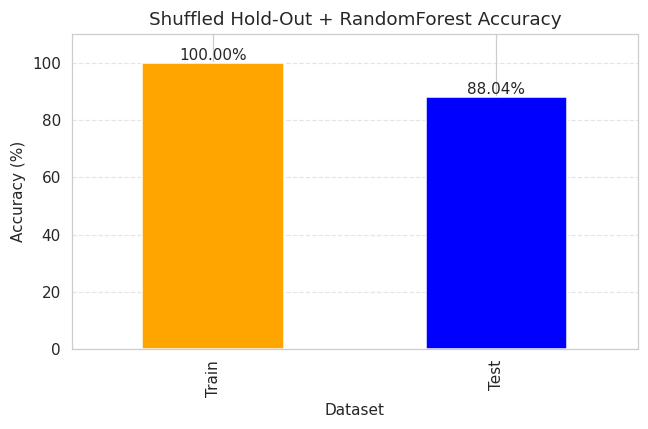

In [ ]:
# 2.Shuffled Hold-Out

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Model create
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Train model
model.fit(X_train, y_train)

# Prediction
train_acc = accuracy_score(y_train, model.predict(X_train)) * 100
test_acc = accuracy_score(y_test, model.predict(X_test)) * 100

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Bar Chart
acc_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_acc, test_acc]
})

results["2. Shuffled Hold-Out"] = test_acc

ax = acc_df.plot(
    x="Dataset",
    y="Accuracy",
    kind="bar",
    figsize=(6, 4),
    legend=False,
    color=["orange", "blue"]
)

plt.title("Shuffled Hold-Out + RandomForest Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("random_forest_shuffled_holdout_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()


---
## 3. Two-Way Hold-Out




Train Accuracy: 100.0
Test Accuracy: 89.4927536231884


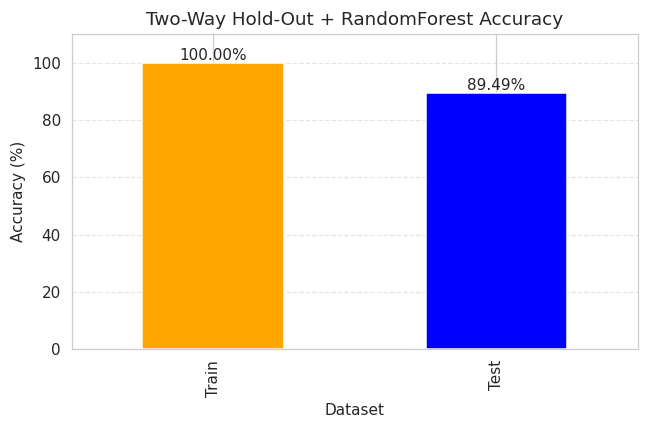

In [ ]:
# 3.Two-Way Hold-Out

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Model create
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Train model
model.fit(X_train, y_train)

# Prediction
train_acc = accuracy_score(y_train, model.predict(X_train)) * 100
test_acc = accuracy_score(y_test, model.predict(X_test)) * 100

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Bar Chart
acc_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_acc, test_acc]
})

results["3. Two-Way Hold-Out"] = test_acc

ax = acc_df.plot(
    x="Dataset",
    y="Accuracy",
    kind="bar",
    figsize=(6, 4),
    legend=False,
    color=["orange", "blue"]
)

plt.title("Two-Way Hold-Out + RandomForest Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("random_forest_two_way_holdout_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()


---
## 4. Three-Way Hold-Out




Train Accuracy: 100.0
Validation Accuracy: 90.21739130434783
Test Accuracy: 85.86956521739131


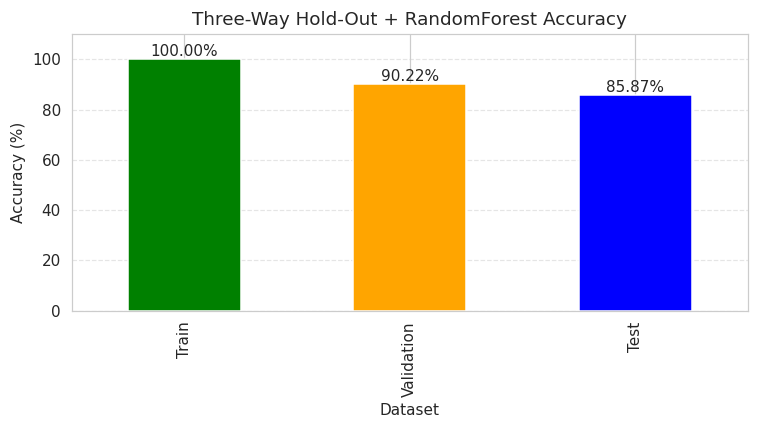

In [ ]:
# 4.Three-Way Hold-Out

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# Model create
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Train model
model.fit(X_train, y_train)

# Prediction
train_acc = accuracy_score(y_train, model.predict(X_train)) * 100
val_acc = accuracy_score(y_val, model.predict(X_val)) * 100
test_acc = accuracy_score(y_test, model.predict(X_test)) * 100

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

# Bar Chart
acc_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Accuracy": [train_acc, val_acc, test_acc]
})

results["4. Three-Way Hold-Out"] = test_acc

ax = acc_df.plot(
    x="Dataset",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    color=["green", "orange", "blue"]
)

plt.title("Three-Way Hold-Out + RandomForest Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("random_forest_three_way_holdout_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()


---
## 5. Stratified Two-Way Hold-Out



Train Accuracy: 100.0
Test Accuracy: 87.5


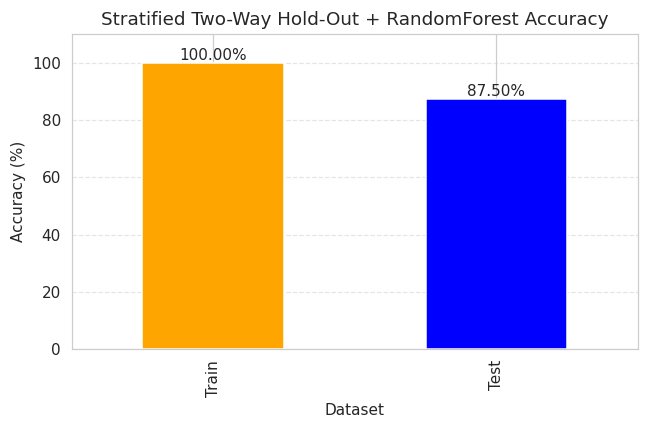

In [ ]:
# 5.Stratified Two-Way Hold-Out

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model create
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Train model
model.fit(X_train, y_train)

# Prediction
train_acc = accuracy_score(y_train, model.predict(X_train)) * 100
test_acc = accuracy_score(y_test, model.predict(X_test)) * 100

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Bar Chart
acc_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_acc, test_acc]
})

results["5. Stratified Two-Way Hold-Out"] = test_acc

ax = acc_df.plot(
    x="Dataset",
    y="Accuracy",
    kind="bar",
    figsize=(6, 4),
    legend=False,
    color=["orange", "blue"]
)

plt.title("Stratified Two-Way Hold-Out + RandomForest Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("random_forest_stratified_two_way_holdout_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()


---
## 6. Stratified Three-Way Hold-Out



Train Accuracy: 100.0
Validation Accuracy: 89.13043478260869
Test Accuracy: 85.86956521739131


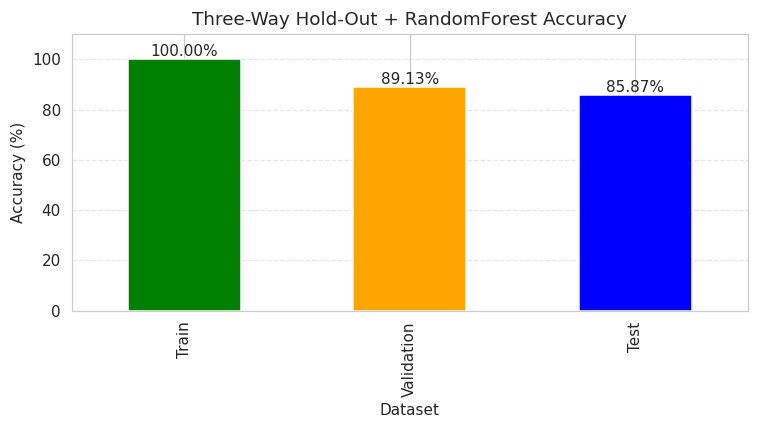

In [ ]:
# 6.Stratified Three-Way Hold-Out

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Model create
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Train model
model.fit(X_train, y_train)

# Prediction
train_acc = accuracy_score(y_train, model.predict(X_train)) * 100
val_acc = accuracy_score(y_val, model.predict(X_val)) * 100
test_acc = accuracy_score(y_test, model.predict(X_test)) * 100

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

# Bar Chart
acc_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Accuracy": [train_acc, val_acc, test_acc]
})

results["6. Stratified Three-Way Hold-Out"] = test_acc

ax = acc_df.plot(
    x="Dataset",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    color=["green", "orange", "blue"]
)

plt.title("Three-Way Hold-Out + RandomForest Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("random_forest_three_way_holdout_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()


---
## 7. k-Fold Cross-Validation




Fold Scores: [0.875      0.83695652 0.82608696 0.81967213 0.75409836]
Mean Accuracy: 82.23627940128296
Std Deviation: 3.9153018421821497


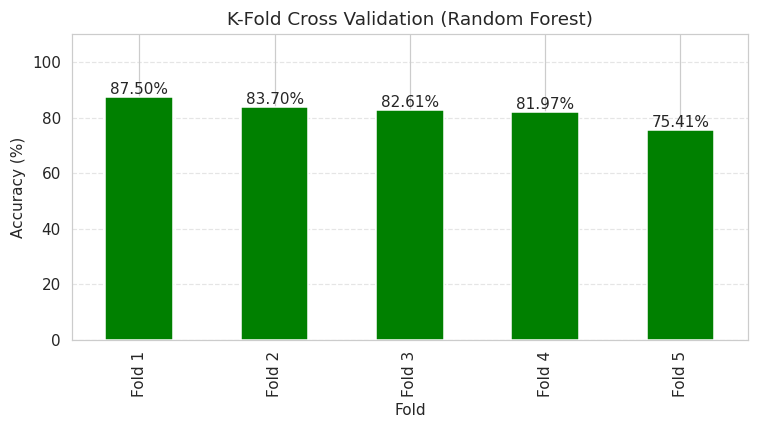

In [ ]:
# 7. k-Fold Cross-Validation

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# K-Fold Cross Validation
scores = cross_val_score(model, X, y, cv=5)

# Results
print("Fold Scores:", scores)
print("Mean Accuracy:", scores.mean() * 100)
print("Std Deviation:", scores.std() * 100)

# Bar Chart
folds = [f"Fold {i+1}" for i in range(len(scores))]

acc_df = pd.DataFrame({
    "Fold": folds,
    "Accuracy": scores * 100
})

results["7. k-Fold CV"] = scores.mean() * 100

ax = acc_df.plot(
    x="Fold",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    color="green"
)

plt.title("K-Fold Cross Validation (Random Forest)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("kfold_cross_validation_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 8. Stratified k-Fold




Fold Scores: [0.88586957 0.85326087 0.8423913  0.87978142 0.84153005]
Mean Accuracy: 86.05666429080543
Std Deviation: 1.8737953538769003


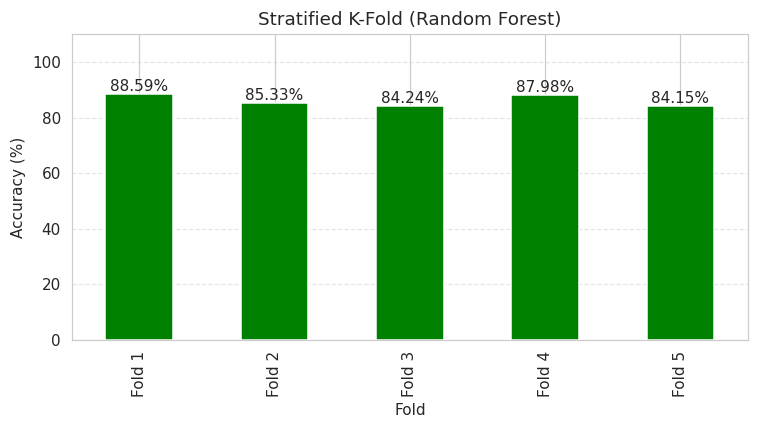

In [ ]:
# 8. Stratified k-Fold

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=skfold)


# Results
print("Fold Scores:", scores)
print("Mean Accuracy:", scores.mean() * 100)
print("Std Deviation:", scores.std() * 100)

# Bar Chart
folds = [f"Fold {i+1}" for i in range(len(scores))]

acc_df = pd.DataFrame({
    "Fold": folds,
    "Accuracy": scores * 100
})

results["8. Stratified k-Fold"] = scores.mean() * 100

ax = acc_df.plot(
    x="Fold",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    color="green"
)

plt.title("Stratified K-Fold (Random Forest)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("stratifiedkfold_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 9. Repeated k-Fold




Fold Scores: [0.88586957 0.85326087 0.8423913  0.87978142 0.84153005 0.84782609
 0.85869565 0.88586957 0.8852459  0.85245902]
Mean Accuracy: 86.32929436920884
Std Deviation: 1.7782258077519815


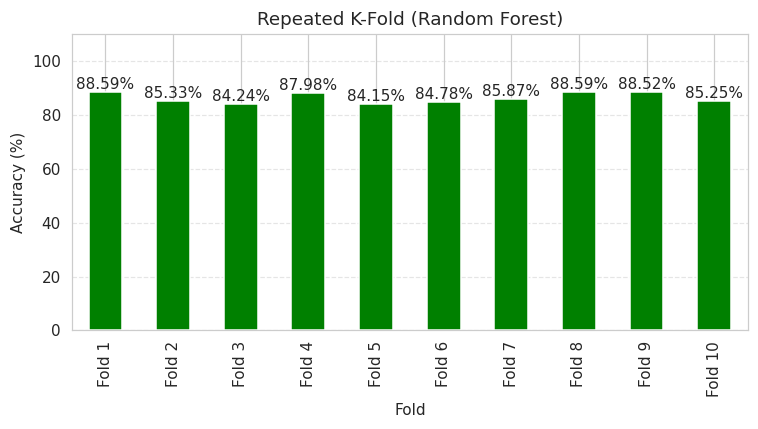

In [ ]:
# 9. Repeated k-Fold

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

rkfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

scores = cross_val_score(model, X, y, cv=rkfold)


# Results
print("Fold Scores:", scores)
print("Mean Accuracy:", scores.mean() * 100)
print("Std Deviation:", scores.std() * 100)

# Bar Chart
folds = [f"Fold {i+1}" for i in range(len(scores))]

acc_df = pd.DataFrame({
    "Fold": folds,
    "Accuracy": scores * 100
})

results["9. Repeated k-Fold"] = scores.mean() * 100

ax = acc_df.plot(
    x="Fold",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    color="green"
)

plt.title("Repeated K-Fold (Random Forest)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("repeated_kfold_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 10. Repeated Stratified k-Fold



Fold Scores: [0.88586957 0.85326087 0.8423913  0.87978142 0.84153005 0.84782609
 0.85869565 0.88586957 0.8852459  0.85245902]
Mean Accuracy: 86.32929436920884
Std Deviation: 1.7782258077519815


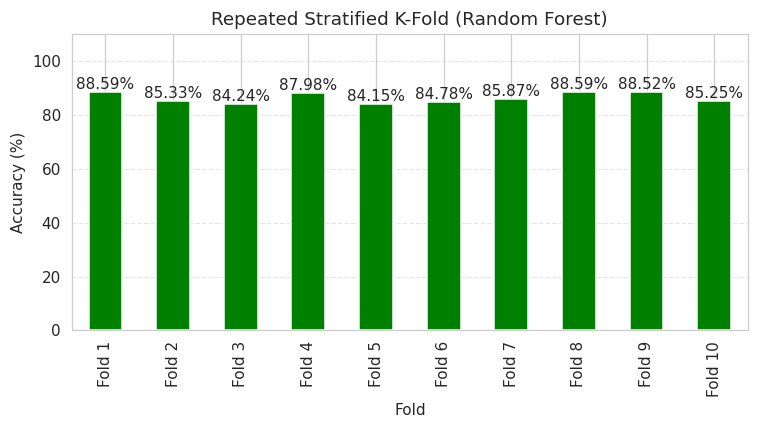

In [ ]:
# 10. Repeated Stratified k-Fold

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

scores = cross_val_score(model, X, y, cv=rskf)


# Results
print("Fold Scores:", scores)
print("Mean Accuracy:", scores.mean() * 100)
print("Std Deviation:", scores.std() * 100)

# Bar Chart
folds = [f"Fold {i+1}" for i in range(len(scores))]

acc_df = pd.DataFrame({
    "Fold": folds,
    "Accuracy": scores * 100
})

results["10. Repeated Stratified k-Fold"] = scores.mean() * 100

ax = acc_df.plot(
    x="Fold",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    color="green"
)

plt.title("Repeated Stratified K-Fold (Random Forest)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("repeated_stratified_kfold_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 11. Leave-One-Out Cross-Validation (LOOCV)



Mean Accuracy: 87.90849673202614
Std Deviation: 32.60285072686073


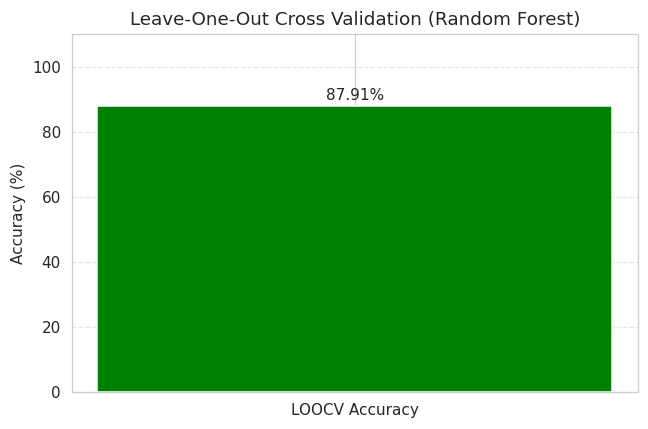

In [ ]:
# 11. Leave-One-Out Cross-Validation (LOOCV)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

loo = LeaveOneOut()
scores = cross_val_score(model, X, y, cv=loo)


# Results
print("Mean Accuracy:", scores.mean() * 100)
print("Std Deviation:", scores.std() * 100)

results["11. LOOCV"] = scores.mean() * 100

# Bar Chart
plt.figure(figsize=(6,4))
plt.bar(["LOOCV Accuracy"], [scores.mean() * 100], color="green")

plt.title("Leave-One-Out Cross Validation (Random Forest)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.text(0, scores.mean()*100 + 2, f"{scores.mean()*100:.2f}%", ha='center')

plt.tight_layout()
plt.savefig("loocv_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 12. Shuffle Split Cross-Validation




Accuracy per split: [0.88043478 0.83152174 0.85869565 0.80434783 0.85869565 0.89130435
 0.86956522 0.88586957 0.875      0.875     ]
Mean Accuracy: 86.30434782608695
Std Deviation: 2.535196476019695


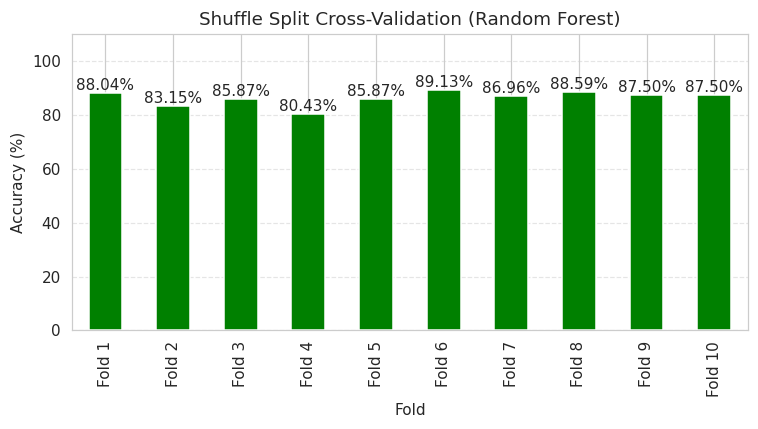

In [ ]:
# 12. Shuffle Split Cross-Validation

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

ss = ShuffleSplit(
    n_splits=10,
    test_size=0.2,
    random_state=42
)
scores = cross_val_score(model, X, y, cv=ss)


# Results
print("Accuracy per split:", scores)
print("Mean Accuracy:", scores.mean() * 100)
print("Std Deviation:", scores.std() * 100)

# Bar Chart
folds = [f"Fold {i+1}" for i in range(len(scores))]

acc_df = pd.DataFrame({
    "Fold": folds,
    "Accuracy": scores * 100
})

results["12. Shuffle Split"] = scores.mean() * 100

ax = acc_df.plot(
    x="Fold",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    color="green"
)

plt.title("Shuffle Split Cross-Validation (Random Forest)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("shuffle_split_cross_validation_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 13. Stratified Shuffle Split



Accuracy per split: [0.875      0.88043478 0.89130435 0.86956522 0.88586957 0.875
 0.83695652 0.82065217 0.86413043 0.85869565]
Mean Accuracy: 86.57608695652173
Std Deviation: 2.0915088483580275


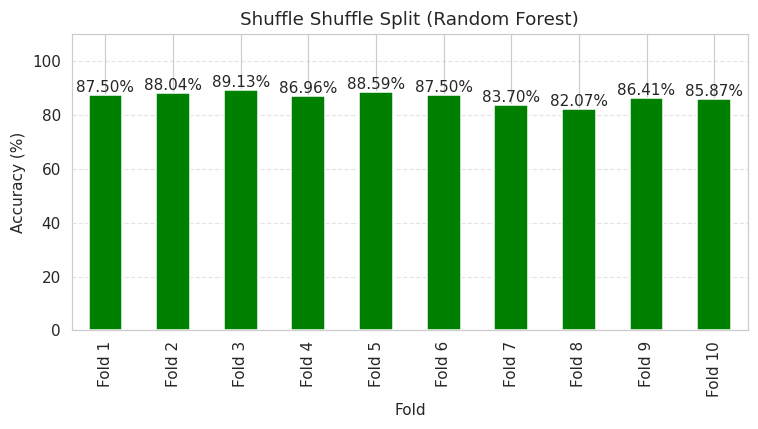

In [ ]:
# 13. Stratified Shuffle Split

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

sss = StratifiedShuffleSplit(
    n_splits=10,
    test_size=0.2,
    random_state=42
)
scores = cross_val_score(model, X, y, cv=sss)


# Results
print("Accuracy per split:", scores)
print("Mean Accuracy:", scores.mean() * 100)
print("Std Deviation:", scores.std() * 100)

# Bar Chart
folds = [f"Fold {i+1}" for i in range(len(scores))]

acc_df = pd.DataFrame({
    "Fold": folds,
    "Accuracy": scores * 100
})

results["13. Stratified Shuffle Split"] = scores.mean() * 100

ax = acc_df.plot(
    x="Fold",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    color="green"
)

plt.title("Shuffle Shuffle Split (Random Forest)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("stratified_shuffle_split_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 14. Group K-Fold Cross-Validation




Accuracy per fold: [0.84491979 0.85135135 0.87677725 0.94736842 0.91428571]
Mean Accuracy: 88.69405047941576
Std Deviation: 3.881987612568956


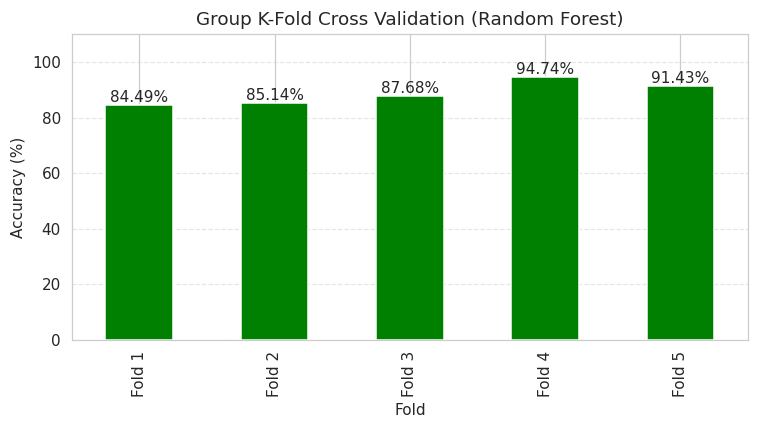

In [ ]:
# 14. Stratified Shuffle Split

df["Group"] = df["Age"] // 10
groups = df["Group"]

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(model, X, y, cv=gkf, groups=groups)


# Results
print("Accuracy per fold:", scores)
print("Mean Accuracy:", scores.mean() * 100)
print("Std Deviation:", scores.std() * 100)

# Bar Chart
folds = [f"Fold {i+1}" for i in range(len(scores))]

acc_df = pd.DataFrame({
    "Fold": folds,
    "Accuracy": scores * 100
})

results["14. Group k-Fold"] = scores.mean() * 100

ax = acc_df.plot(
    x="Fold",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    color="green"
)

plt.title("Group K-Fold Cross Validation (Random Forest)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("group_kfold_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 15. Stratified Group k-Fold



Accuracy per fold: [0.84491979 0.87677725 0.85135135 0.94736842 0.91428571]
Mean Accuracy: 88.69405047941576
Std Deviation: 3.881987612568956


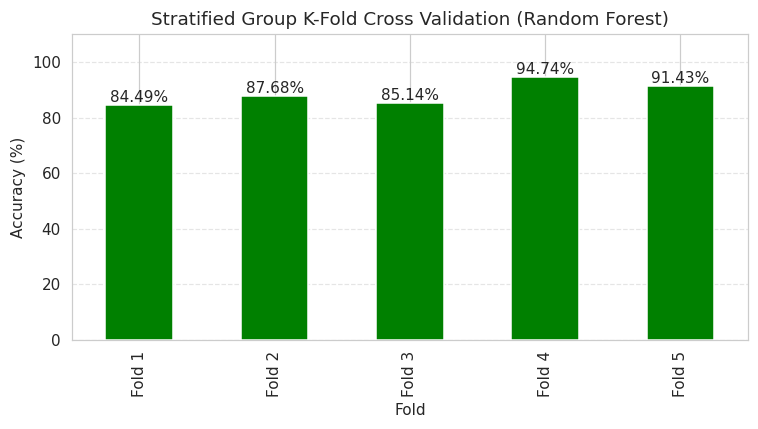

In [ ]:
# 15. Stratified Shuffle Split

df["Group"] = df["Age"] // 10
groups = df["Group"]

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

sgkf = StratifiedGroupKFold(n_splits=5)
scores = cross_val_score(model, X, y, cv=sgkf, groups=groups)


# Results
print("Accuracy per fold:", scores)
print("Mean Accuracy:", scores.mean() * 100)
print("Std Deviation:", scores.std() * 100)

# Bar Chart
folds = [f"Fold {i+1}" for i in range(len(scores))]

acc_df = pd.DataFrame({
    "Fold": folds,
    "Accuracy": scores * 100
})

results["15. Stratified Group k-Fold"] = scores.mean() * 100

ax = acc_df.plot(
    x="Fold",
    y="Accuracy",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    color="green"
)

plt.title("Stratified Group K-Fold Cross Validation (Random Forest)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Percentage label on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("stratified_group_kfold_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 16. Bootstrap Sampling (with replacement)



Train Accuracy: 100.0
Test Accuracy: 88.04347826086956


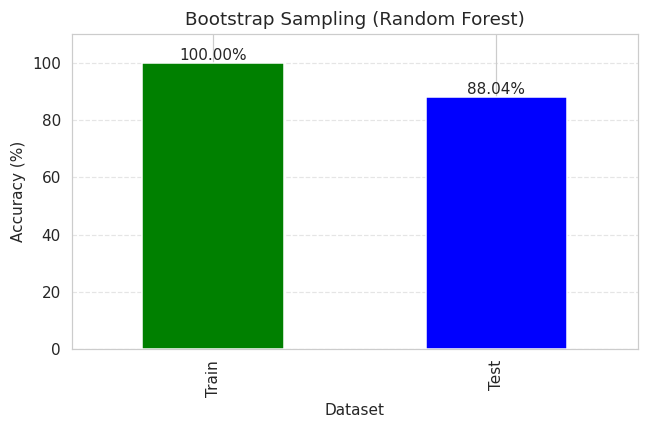

In [ ]:
# 16. Bootstrap Sampling (with replacement)

bootstrap_sample = resample(
    df,
    replace=True,
    n_samples=len(df),
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediction
train_acc = accuracy_score(y_train, model.predict(X_train)) * 100
test_acc = accuracy_score(y_test, model.predict(X_test)) * 100

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Bar Chart
acc_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_acc, test_acc]
})

results["16. Bootstrap (OOB-style)"] = test_acc

ax = acc_df.plot(
    x="Dataset",
    y="Accuracy",
    kind="bar",
    figsize=(6, 4),
    color=["green", "blue"],
    legend=False
)

plt.title("Bootstrap Sampling (Random Forest)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.savefig("bootstrap_sampling_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()


---
## All Techniques — Accuracy Comparison



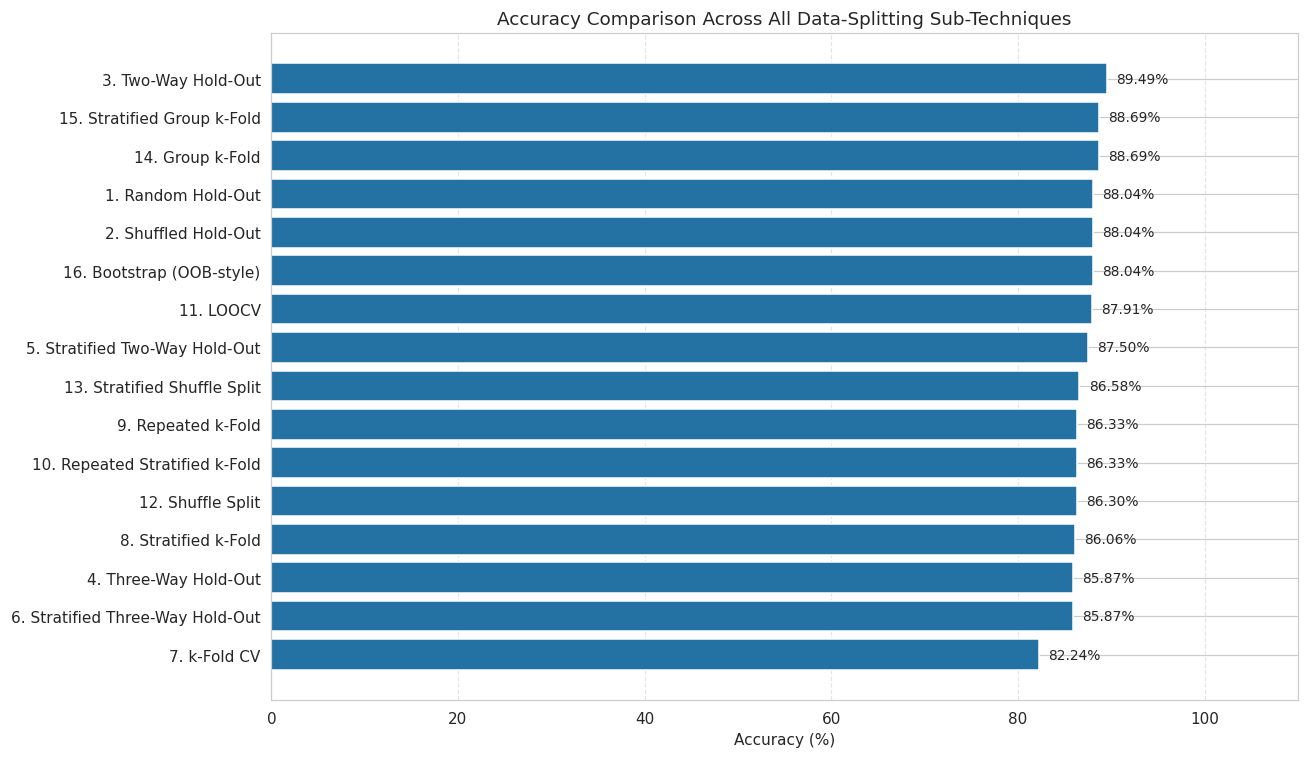

In [ ]:
# Final Cross-Technique Accuracy Comparison Plot
results_df = pd.DataFrame({
    "Technique": list(results.keys()),
    "Accuracy": list(results.values())
}).sort_values("Accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(results_df["Technique"], results_df["Accuracy"], color="#2471A3")

ax.set_xlabel("Accuracy (%)")
ax.set_title("Accuracy Comparison Across All Data-Splitting Sub-Techniques")
ax.set_xlim(0, 110)
ax.invert_yaxis()  # highest accuracy at top
ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar, acc in zip(bars, results_df["Accuracy"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             f"{acc:.2f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("all_techniques_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
